<a href="https://colab.research.google.com/github/anselmo-torres/TP2---LAB---Python/blob/main/Ejercicio_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 ESCENARIO 1: Argentina + Brasil (Train/Test Split)
Accuracy KNN (Sin PCA):       0.50
Accuracy Logística (Sin PCA): 0.67
Varianza explicada PC1+PC2 (ARG+BRA): 65.50%
Accuracy KNN (Con PCA):       0.50
Accuracy Logística (Con PCA): 0.83

 ESCENARIO 2: Transferencia (Entrenar en ARG+BRA -> Predecir en USA)
Entrenando con 18 casos de Argentina + Brasil.
Testeando con 12 casos de USA.
Accuracy KNN (Sin PCA):       0.50
Accuracy Logística (Sin PCA): 0.67
Varianza explicada PC1+PC2 (Transfer): 57.65%
Accuracy Logística (Con PCA): 0.50
Accuracy KNN (Con PCA):       0.67


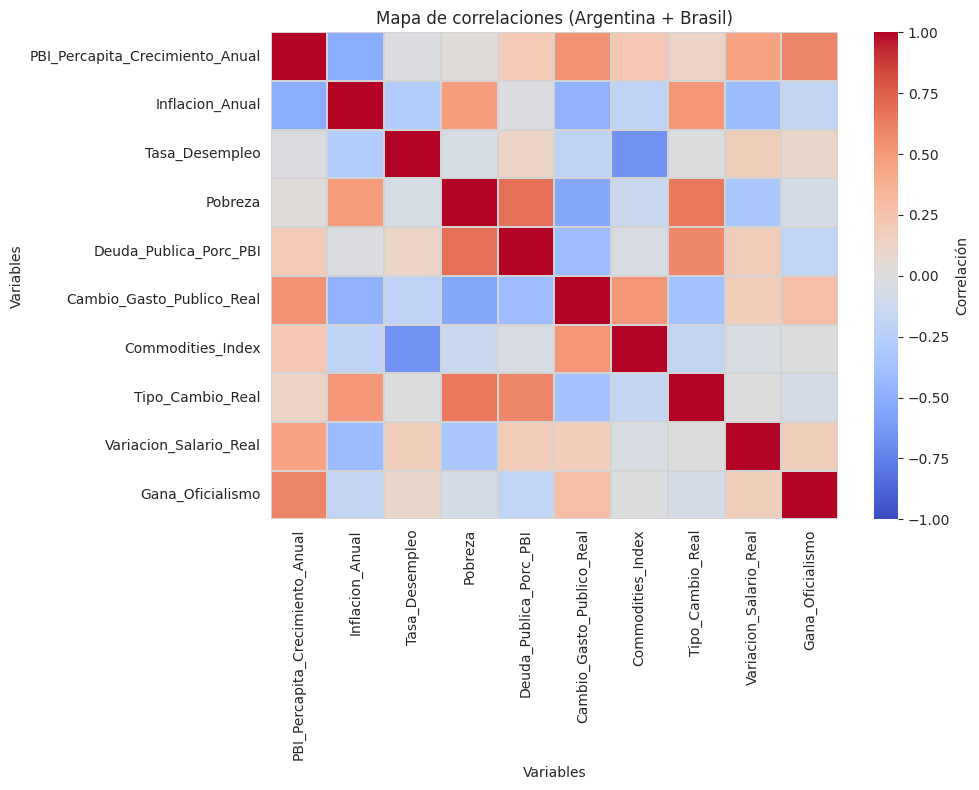

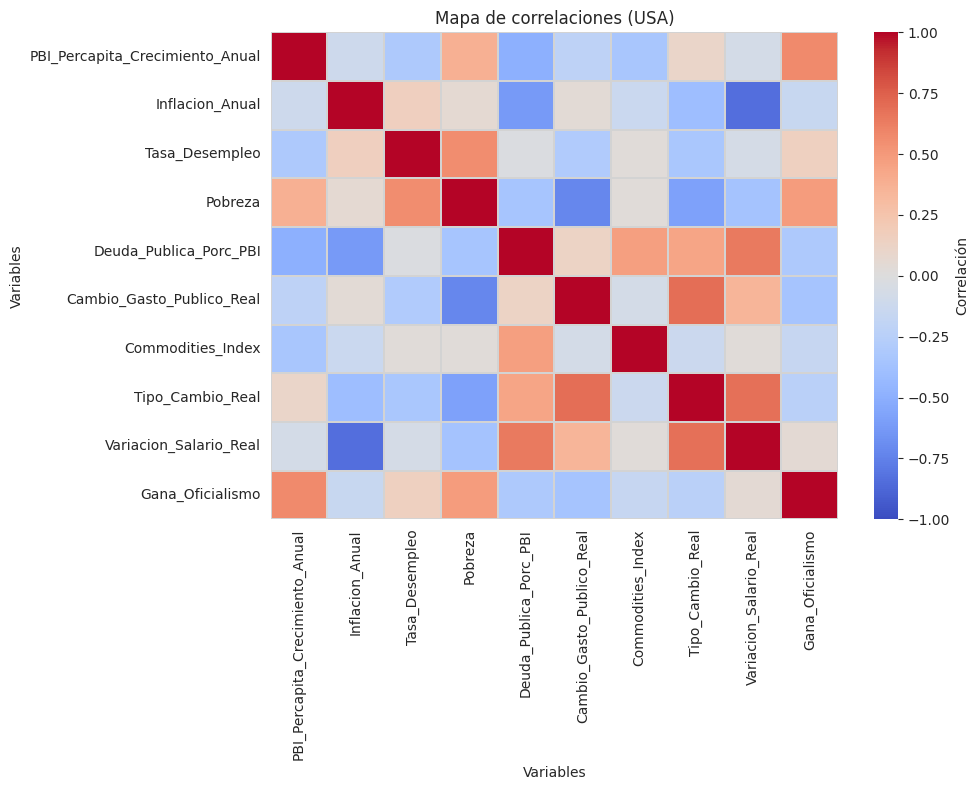

/tmp/ipython-input-1465532707.py:262: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.array(feature_names)[idx], rotation=45, ha="right")
/tmp/ipython-input-1465532707.py:262: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.array(feature_names)[idx], rotation=45, ha="right")


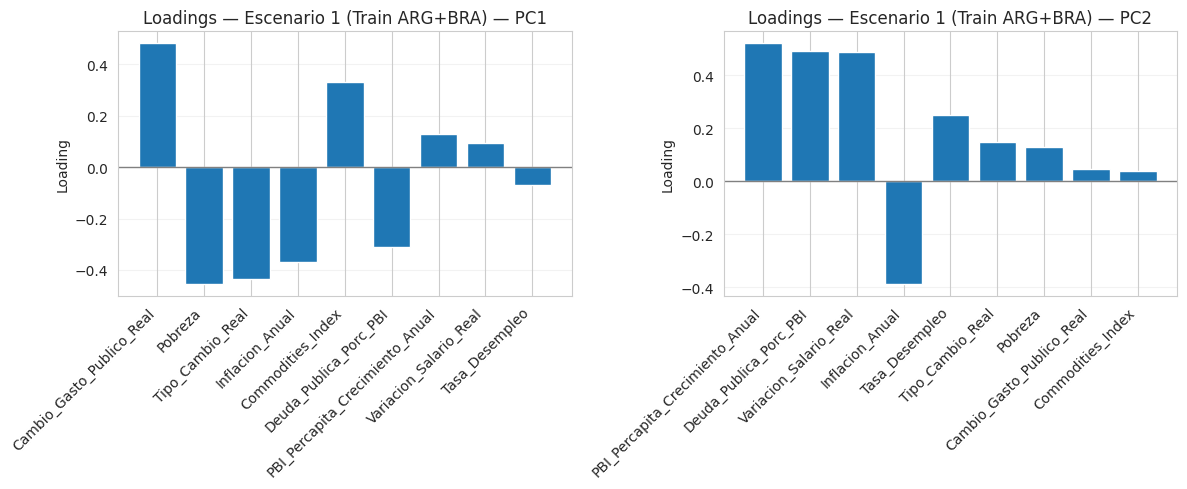

/tmp/ipython-input-1465532707.py:262: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.array(feature_names)[idx], rotation=45, ha="right")
/tmp/ipython-input-1465532707.py:262: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.array(feature_names)[idx], rotation=45, ha="right")


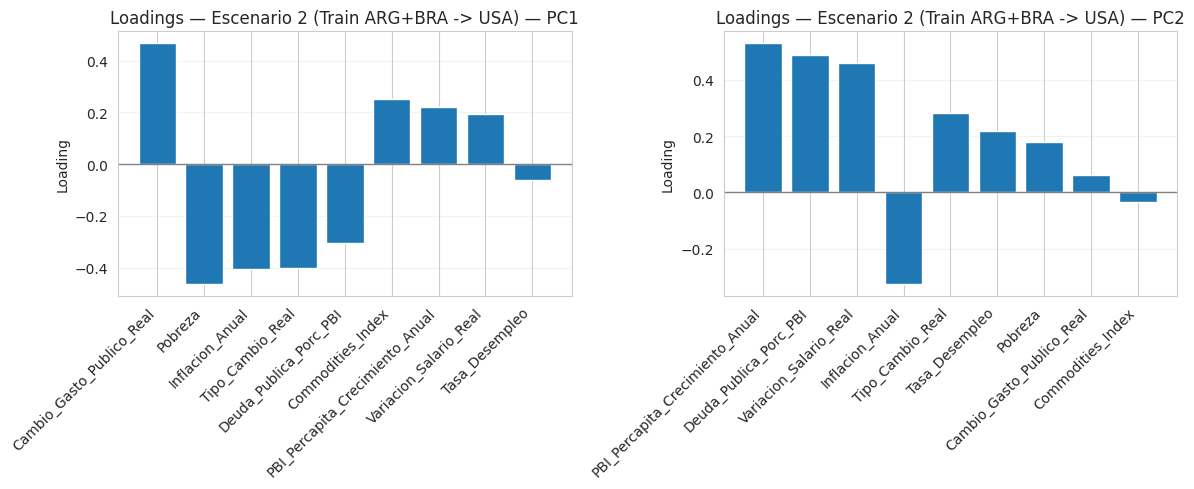

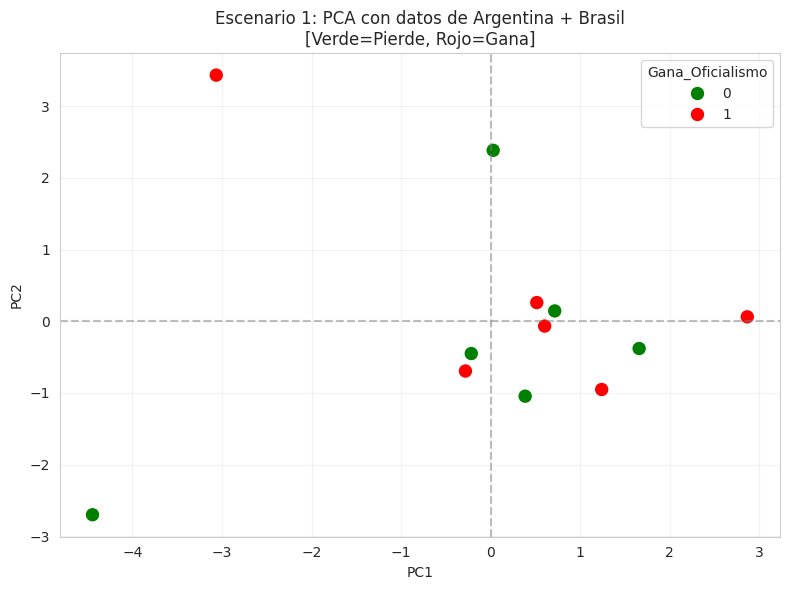

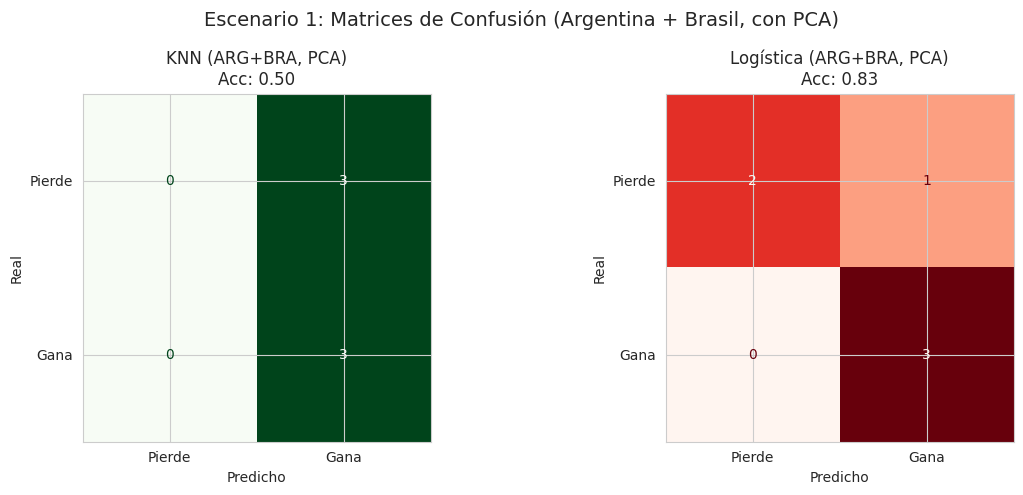

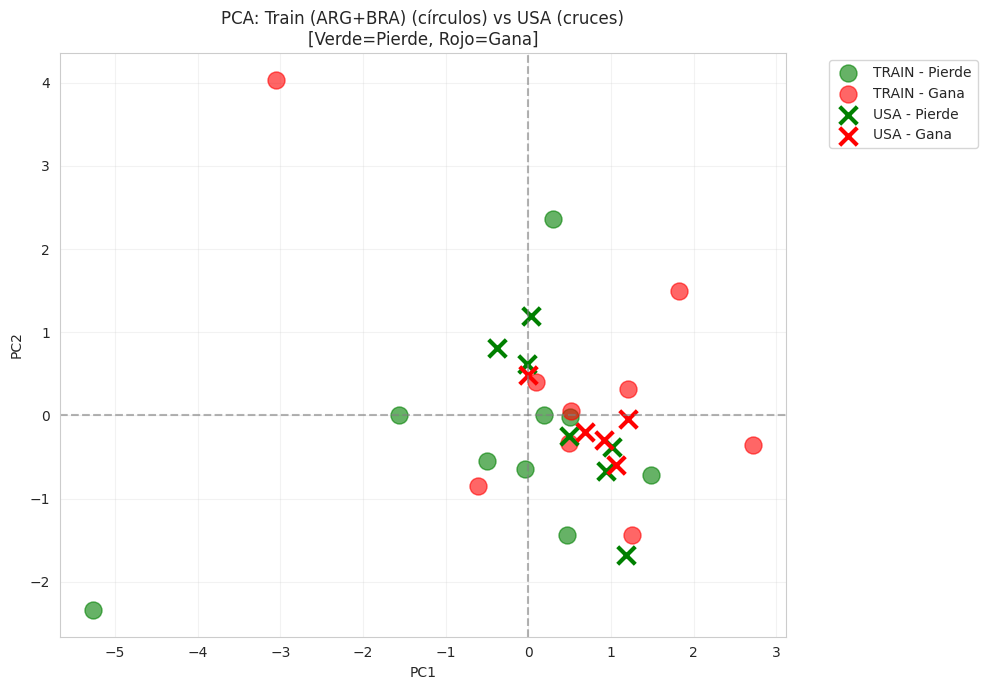

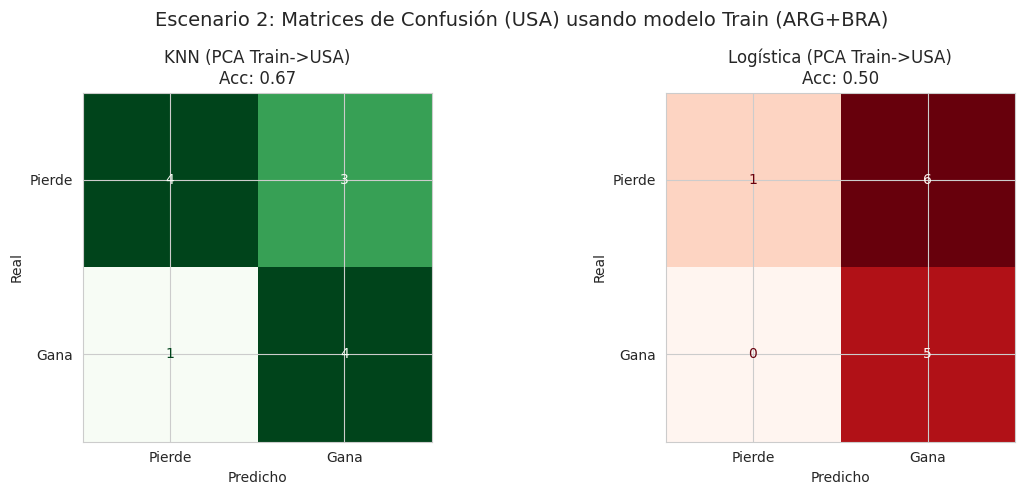

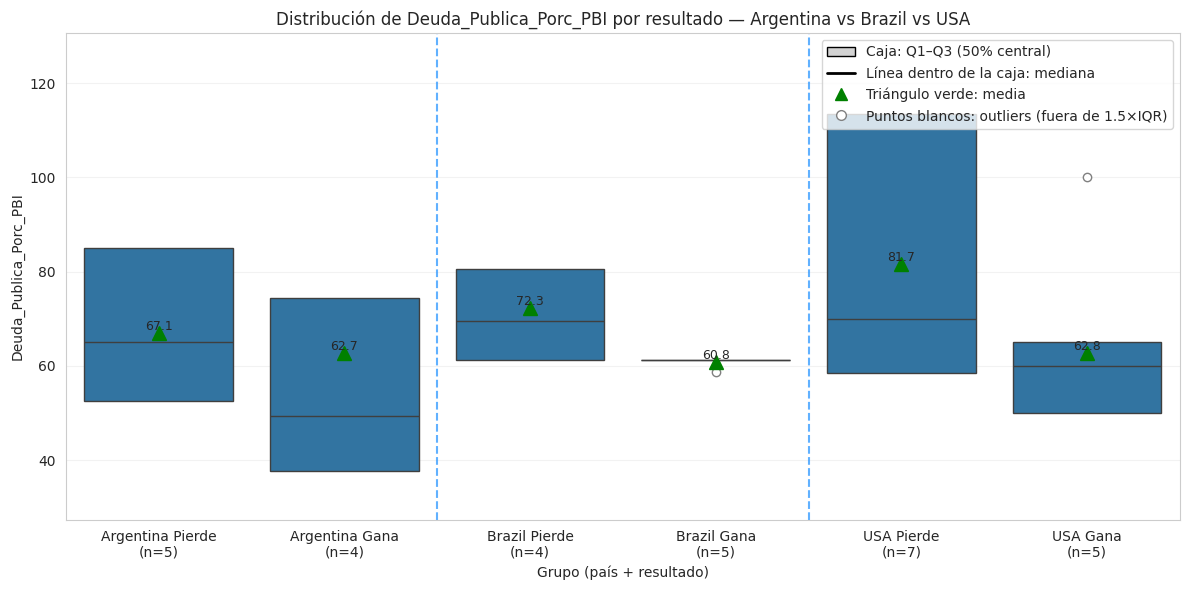

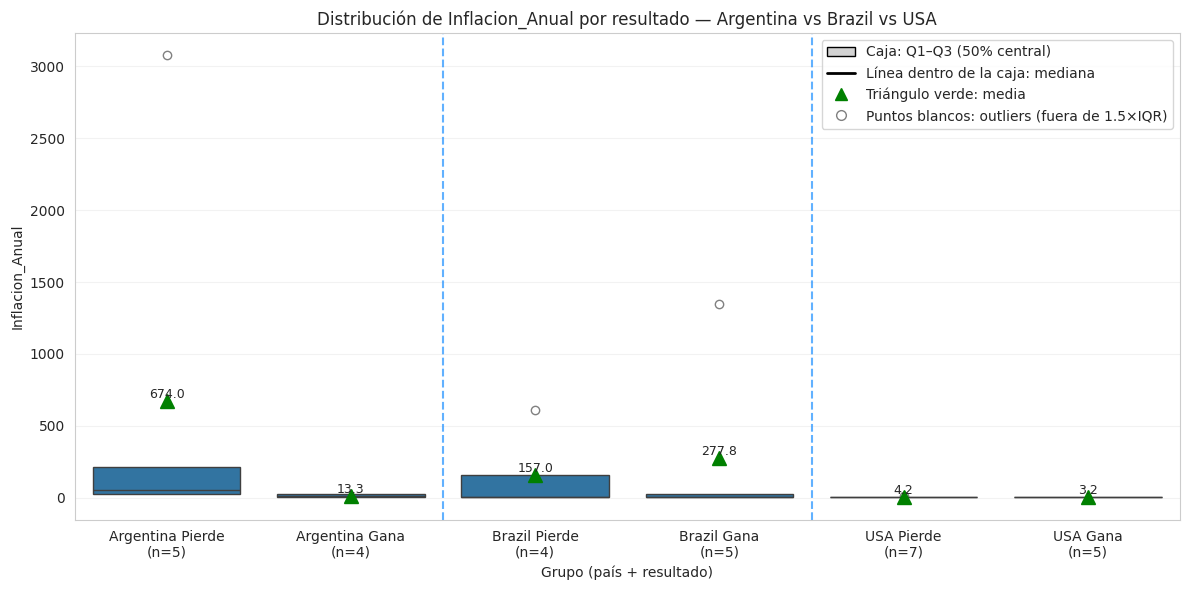

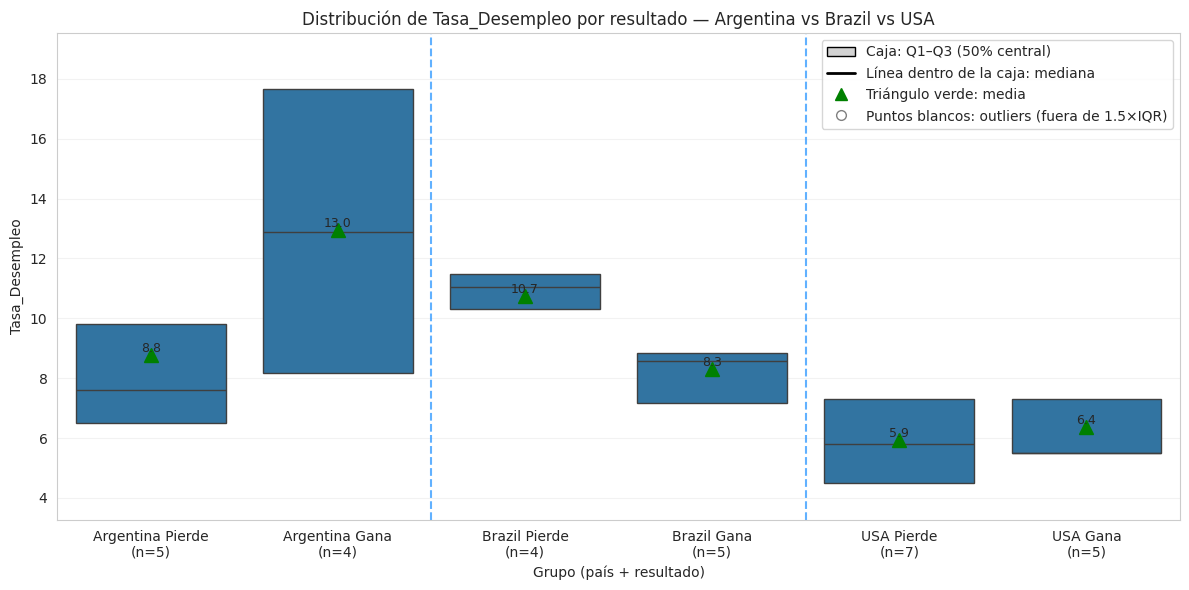

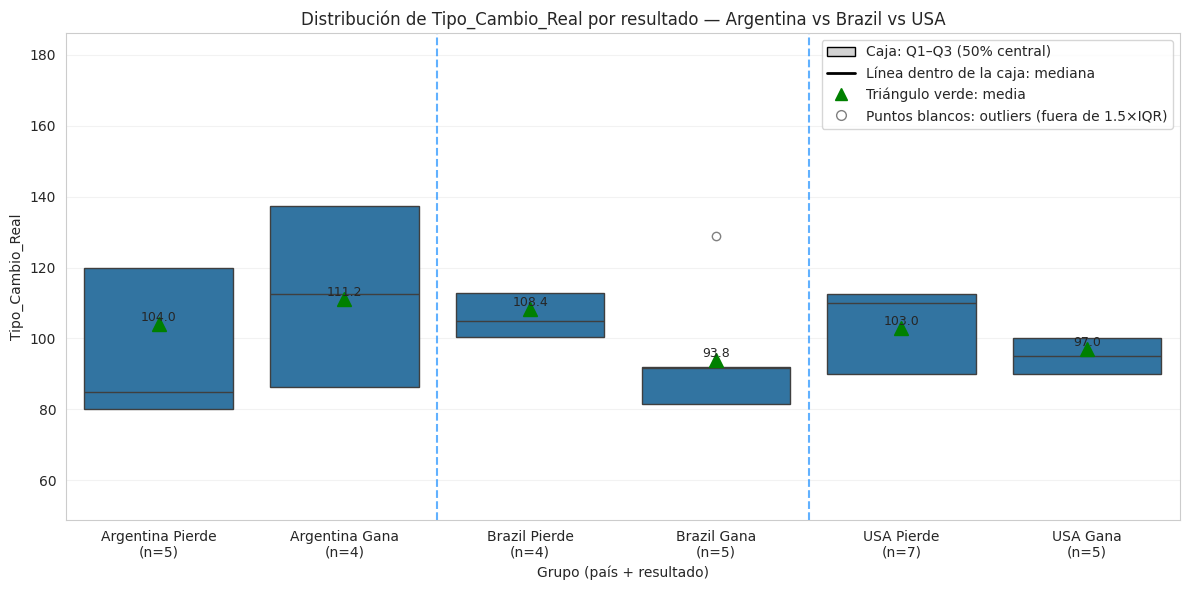

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay




##########################Base de Datos#########################################

PREDICTORES_ECONOMICOS = [
    'PBI_Percapita_Crecimiento_Anual', 'Inflacion_Anual', 'Tasa_Desempleo',
    'Pobreza', 'Deuda_Publica_Porc_PBI', 'Cambio_Gasto_Publico_Real',
    'Commodities_Index', 'Tipo_Cambio_Real', 'Variacion_Salario_Real'
]
EVENTO_ELECTORAL = 'Gana_Oficialismo'

dataset_argentina = {
    'Pais': ['Argentina'] * 9,
    'Año': [1989, 1995, 1999, 2003, 2007, 2011, 2015, 2019, 2023],
    'PBI_Percapita_Crecimiento_Anual': [-8.2, -4.0, -4.5, 8.0, 8.0, 5.0, 1.6, -3.0, -2.5],
    'Inflacion_Anual': [3079.0, 1.6, -1.2, 3.7, 25.0, 23.0, 27.0, 53.8, 211.4],
    'Tasa_Desempleo': [7.6, 18.8, 14.3, 17.3, 8.5, 7.2, 6.5, 9.8, 5.7],
    'Pobreza': [47.3, 22.2, 26.7, 54.7, 30.0, 25.0, 30.0, 35.5, 41.7],
    'Deuda_Publica_Porc_PBI': [65.0, 34.0, 43.0, 118.0, 60.0, 38.9, 52.6, 89.8, 85.0],
    'Cambio_Gasto_Publico_Real': [-10.5, 1.2, -2.0, -5.0, 12.0, 8.5, 5.0, -7.0, 1.5],
    'Commodities_Index': [250, 260, 190, 230, 350, 480, 380, 330, 520],
    'Tipo_Cambio_Real': [180.0, 60.0, 55.0, 160.0, 130.0, 95.0, 80.0, 120.0, 85.0],
    'Variacion_Salario_Real': [-22.0, -1.5, 1.0, 11.0, 15.0, 4.0, -3.0, -8.0, -12.0],
    'Gana_Oficialismo': [0, 1, 0, 1, 1, 1, 0, 0, 0]
}

dataset_usa = {
    'Pais': ['USA'] * 12,
    'Año': [1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020, 2024],
    'PBI_Percapita_Crecimiento_Anual': [-0.3, 7.2, 4.2, 3.5, 3.8, 4.1, 3.8, -0.1, 2.2, 1.7, -3.4, 2.8],
    'Inflacion_Anual': [13.5, 4.3, 4.1, 3.0, 2.9, 3.4, 2.7, 3.8, 2.1, 1.3, 1.2, 2.9],
    'Tasa_Desempleo': [7.2, 7.3, 5.5, 7.4, 5.4, 4.0, 5.5, 5.8, 8.1, 4.9, 8.1, 4.1],
    'Pobreza': [13.0, 14.4, 13.0, 14.8, 13.7, 11.3, 12.7, 13.2, 15.0, 12.7, 11.4, 11.5],
    'Deuda_Publica_Porc_PBI': [32.0, 39.0, 50.0, 62.0, 65.0, 55.0, 60.0, 70.0, 100.0, 105.0, 126.0, 122.0],
    'Cambio_Gasto_Publico_Real': [2.0, 3.5, 1.5, -0.5, 1.0, 2.5, 2.0, 3.0, -2.3, 1.8, 4.5, 3.8],
    'Commodities_Index': [37.0, 29.0, 16.0, 20.0, 22.0, 30.0, 41.0, 99.0, 94.0, 43.0, 39.0, 78.0],
    'Tipo_Cambio_Real': [86.0, 115.0, 90.0, 92.0, 95.0, 110.0, 100.0, 88.0, 85.0, 110.0, 115.0, 120.0],
    'Variacion_Salario_Real': [-4.5, 1.0, -0.5, -1.0, 0.5, 1.2, 0.4, -0.5, 0.3, 1.1, 4.0, 0.8],
    'Gana_Oficialismo': [0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0]
}

dataset_Brazil = {
    'Pais': ['Brazil'] * 9,
    'Año': [1989, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022],
    'PBI_Percapita_Crecimiento_Anual': [-1.5, 0.64, 1, 0.9, 2.3, 3.6, 1.5, -1.6, 0.92],
    'Inflacion_Anual': [608.8, 1347, 22.9, 6.79, 8, 4.8, 6.1, 6.2, 6.1],
    'Tasa_Desempleo': [np.nan, 6.64, 8.57, 10.82, 10.37, 8.84, 7.16, 11.3, 12],
    'Pobreza': [37.2, 38.55, 35.32, 34.76, 33.2, 30.73, 28.5, 28.67, 27.15],
    'Deuda_Publica_Porc_PBI': [np.nan, np.nan, np.nan, np.nan, np.nan, 61.31, 58.71, 77.8, 88.84],
    'Cambio_Gasto_Publico_Real': [np.nan, np.nan, np.nan, 0.48, 1.76, -1.46, -0.1, 5.07, -1.78],
    'Commodities_Index': [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    'Tipo_Cambio_Real': [108.51, 91.77, 75.25, 98.28, 128.85, 91.82, 81.50, 101.17, 125.56],
    'Variacion_Salario_Real': [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 28.1, -2.7, 53.1],
    'Gana_Oficialismo': [0, 1, 1, 0, 1, 1, 1, 0, 0]
}

df_arg = pd.DataFrame(dataset_argentina).sort_values("Año").reset_index(drop=True)
df_usa = pd.DataFrame(dataset_usa).sort_values("Año").reset_index(drop=True)
df_bra = pd.DataFrame(dataset_Brazil).sort_values("Año").reset_index(drop=True)

df_final = pd.concat([df_arg, df_bra, df_usa], ignore_index=True)
df_latam = pd.concat([df_arg, df_bra], ignore_index=True)

df_latam[PREDICTORES_ECONOMICOS] = df_latam[PREDICTORES_ECONOMICOS].fillna(
    df_latam[PREDICTORES_ECONOMICOS].median(numeric_only=True)
) #Rellenamos los NA con la media




##########################Modelo 1: Train/test en LATAM#########################
print("\n" + "="*60)
print(" ESCENARIO 1: Argentina + Brasil (Train/Test Split)")
print("="*60)

X = df_latam[PREDICTORES_ECONOMICOS]
y = df_latam[EVENTO_ELECTORAL]

#Split 70/30
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#Hago el escalado
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

#Modelo sin PCA
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

log = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
log.fit(X_train, y_train)
y_pred_log = log.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

print(f"Accuracy KNN (Sin PCA):       {acc_knn:.2f}")
print(f"Accuracy Logística (Sin PCA): {acc_log:.2f}")

#Modelo con PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"Varianza explicada PC1+PC2 (ARG+BRA): {pca.explained_variance_ratio_.sum():.2%}")

knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_train_pca, y_train)
y_pred_knn_pca = knn_pca.predict(X_test_pca)
acc_knn_pca = accuracy_score(y_test, y_pred_knn_pca)

log_pca = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
log_pca.fit(X_train_pca, y_train)
y_pred_log_pca = log_pca.predict(X_test_pca)
acc_log_pca = accuracy_score(y_test, y_pred_log_pca)

print(f"Accuracy KNN (Con PCA):       {acc_knn_pca:.2f}")
print(f"Accuracy Logística (Con PCA): {acc_log_pca:.2f}")

cm_knn_s1 = confusion_matrix(y_test, y_pred_knn_pca)
cm_log_s1 = confusion_matrix(y_test, y_pred_log_pca)
y_train_s1 = y_train.copy()
y_test_s1 = y_test.copy()
X_train_pca_s1 = X_train_pca.copy()
X_test_pca_s1 = X_test_pca.copy()




###########################Modelo 2: Transferencia a USA#######################

print("\n" + "="*60)
print(" ESCENARIO 2: Transferencia (Entrenar en ARG+BRA -> Predecir en USA)")
print("="*60)

X_train_raw = df_latam[PREDICTORES_ECONOMICOS]
y_train = df_latam[EVENTO_ELECTORAL]
X_test_raw = df_usa[PREDICTORES_ECONOMICOS]
y_test = df_usa[EVENTO_ELECTORAL]

print(f"Entrenando con {len(X_train_raw)} casos de Argentina + Brasil.")
print(f"Testeando con {len(X_test_raw)} casos de USA.")

#Hago el escalado de nuevo
scaler_transfer = StandardScaler()
X_train_sc = scaler_transfer.fit_transform(X_train_raw)
X_test_sc  = scaler_transfer.transform(X_test_raw)

#Modelo sin PCA
knn.fit(X_train_sc, y_train)
y_pred_knn_sin = knn.predict(X_test_sc)
acc_knn_sin = accuracy_score(y_test, y_pred_knn_sin)

log.fit(X_train_sc, y_train)
y_pred_log_sin = log.predict(X_test_sc)
acc_log_sin = accuracy_score(y_test, y_pred_log_sin)

print(f"Accuracy KNN (Sin PCA):       {acc_knn_sin:.2f}")
print(f"Accuracy Logística (Sin PCA): {acc_log_sin:.2f}")

#Modelo con PCA
pca_transfer = PCA(n_components=2, random_state=42)
X_train_pca_tr = pca_transfer.fit_transform(X_train_sc)
X_test_pca_tr  = pca_transfer.transform(X_test_sc)

print(f"Varianza explicada PC1+PC2 (Transfer): {pca_transfer.explained_variance_ratio_.sum():.2%}")

#Entreno sobre PCA
log.fit(X_train_pca_tr, y_train)
knn.fit(X_train_pca_tr, y_train)

y_pred_log_pca_tr = log.predict(X_test_pca_tr)
y_pred_knn_pca_tr = knn.predict(X_test_pca_tr)

acc_log_pca_tr = accuracy_score(y_test, y_pred_log_pca_tr)
acc_knn_pca_tr = accuracy_score(y_test, y_pred_knn_pca_tr)

print(f"Accuracy Logística (Con PCA): {acc_log_pca_tr:.2f}")
print(f"Accuracy KNN (Con PCA):       {acc_knn_pca_tr:.2f}")

cm_knn_s2 = confusion_matrix(y_test, y_pred_knn_pca_tr)
cm_log_s2 = confusion_matrix(y_test, y_pred_log_pca_tr)
y_train_s2 = y_train.copy()
y_test_s2 = y_test.copy()
X_train_pca_s2 = X_train_pca_tr.copy()
X_test_pca_s2 = X_test_pca_tr.copy()




#################################Mapa de Correlaciones########################
sns.set_style("whitegrid")
cols_corr = PREDICTORES_ECONOMICOS + [EVENTO_ELECTORAL]

#ARG+BRA
plt.figure(figsize=(10, 8))
corr_latam = df_latam[cols_corr].corr(numeric_only=True)
sns.heatmap(
    corr_latam,
    annot=False,
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),
    linewidths=0.3,
    linecolor="lightgray",
    cbar_kws={"label": "Correlación"}
)
plt.title("Mapa de correlaciones (Argentina + Brasil)")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

#USA
plt.figure(figsize=(10, 8))
corr_usa = df_usa[cols_corr].corr(numeric_only=True)
sns.heatmap(
    corr_usa,
    annot=False,
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),
    linewidths=0.3,
    linecolor="lightgray",
    cbar_kws={"label": "Correlación"}
)
plt.title("Mapa de correlaciones (USA)")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

###########################PCA Loadings y Boxplots#############################

def plot_pca_loadings(pca, feature_names, title="PCA Loadings", pcs=(1, 2)):
    loadings = pca.components_.T

    plt.figure(figsize=(12, 5))
    for i, pc in enumerate(pcs):
        ax = plt.subplot(1, len(pcs), i + 1)
        vals = loadings[:, pc - 1]
        idx = np.argsort(np.abs(vals))[::-1]  #Ordeno por magnitud
        ax.bar(np.array(feature_names)[idx], vals[idx])
        ax.axhline(0, color="gray", linewidth=1)
        ax.set_title(f"{title} — PC{pc}")
        ax.set_xticklabels(np.array(feature_names)[idx], rotation=45, ha="right")
        ax.set_ylabel("Loading")
        ax.grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()


def boxplot_pais_resultado(df, variable, paises=("Argentina", "Brazil", "USA"),
                           pais_col="Pais", y_col="Gana_Oficialismo", title=None):
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    dfp = df.copy()
    dfp = dfp[dfp[pais_col].isin(paises)].copy()
    dfp["Resultado"] = dfp[y_col].map({0: "Pierde", 1: "Gana"})
    dfp["Grupo"] = dfp[pais_col] + " " + dfp["Resultado"]

    order = []
    for p in paises:
        order += [f"{p} Pierde", f"{p} Gana"]

    stats = dfp.groupby("Grupo")[variable].agg(["count", "mean"])
    label_map = {g: f"{g}\n(n={int(stats.loc[g, 'count'])})" for g in stats.index}

    dfp["Grupo_lbl"] = dfp["Grupo"].map(label_map)
    order_lbl = [label_map[g] for g in order if g in label_map]

    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(
        data=dfp, x="Grupo_lbl", y=variable, order=order_lbl,
        showmeans=True,
        meanprops={"marker": "^", "markerfacecolor": "green", "markeredgecolor": "green", "markersize": 10},
        showfliers=True,
        flierprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "gray",
                    "markersize": 6, "linestyle": "none"},
        whiskerprops={"linewidth": 0},
        capprops={"linewidth": 0}
    )

    for i, g in enumerate([g for g in order if g in stats.index]):
        m = stats.loc[g, "mean"]
        ax.text(i, m, f"{m:.1f}", ha="center", va="bottom", fontsize=9)

    for k in range(1, len(paises)):
        ax.axvline(x=2*k - 0.5, color="dodgerblue", linestyle="--", alpha=0.7)

    ax.set_xlabel("Grupo (país + resultado)")
    ax.set_ylabel(variable)

    if title is None:
        title = f"Distribución de {variable} por resultado — " + " vs ".join(paises)
    ax.set_title(title)

    legend_elems = [
        Patch(facecolor="lightgray", edgecolor="black", label="Caja: Q1–Q3 (50% central)"),
        Line2D([0], [0], color="black", lw=2, label="Línea dentro de la caja: mediana"),
        Line2D([0], [0], marker="^", color="green", markerfacecolor="green",
               markersize=9, linestyle="None", label="Triángulo verde: media"),
        Line2D([0], [0], marker="o", color="gray", markerfacecolor="white",
               markersize=7, linestyle="None",
               label="Puntos blancos: outliers (fuera de 1.5×IQR)")
    ]
    ax.legend(handles=legend_elems, loc="upper right", frameon=True)

    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


#PCA LOADINGS
plot_pca_loadings(pca, PREDICTORES_ECONOMICOS, title="Loadings — Escenario 1 (Train ARG+BRA)")
plot_pca_loadings(pca_transfer, PREDICTORES_ECONOMICOS, title="Loadings — Escenario 2 (Train ARG+BRA -> USA)")

#Gráfico PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_pca_s1[:, 0], y=X_train_pca_s1[:, 1],
    hue=y_train_s1,
    palette={0: "green", 1: "red"},
    s=110
)
plt.axvline(0, color="gray", linestyle="--", alpha=0.5)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.title("Escenario 1: PCA con datos de Argentina + Brasil\n[Verde=Pierde, Rojo=Gana]")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

#Matrices de confusión con PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_knn_s1, display_labels=["Pierde", "Gana"]).plot(ax=ax1, cmap="Greens", colorbar=False)
ax1.set_title(f"KNN (ARG+BRA, PCA)\nAcc: {acc_knn_pca:.2f}")
ax1.set_xlabel("Predicho")
ax1.set_ylabel("Real")

ConfusionMatrixDisplay(cm_log_s1, display_labels=["Pierde", "Gana"]).plot(ax=ax2, cmap="Reds", colorbar=False)
ax2.set_title(f"Logística (ARG+BRA, PCA)\nAcc: {acc_log_pca:.2f}")
ax2.set_xlabel("Predicho")
ax2.set_ylabel("Real")

plt.suptitle("Escenario 1: Matrices de Confusión (Argentina + Brasil, con PCA)", fontsize=14)
plt.tight_layout()
plt.show()

#Grafico PCA
plt.figure(figsize=(10, 7))

colores = {0: "green", 1: "red"}
etiquetas = {0: "Pierde", 1: "Gana"}
for r in [0, 1]:
    subset = X_train_pca_s2[y_train_s2.to_numpy() == r]
    if len(subset) > 0:
        plt.scatter(
            subset[:, 0], subset[:, 1],
            c=colores[r], marker="o", s=150, alpha=0.6,
            label=f"TRAIN - {etiquetas[r]}"
        )
for r in [0, 1]:
    subset = X_test_pca_s2[y_test_s2.to_numpy() == r]
    if len(subset) > 0:
        plt.scatter(
            subset[:, 0], subset[:, 1],
            c=colores[r], marker="x", s=160, linewidths=3,
            label=f"USA - {etiquetas[r]}"
        )

plt.axhline(0, color="grey", ls="--", alpha=0.6)
plt.axvline(0, color="grey", ls="--", alpha=0.6)
plt.title("PCA: Train (ARG+BRA) (círculos) vs USA (cruces)\n[Verde=Pierde, Rojo=Gana]")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#Matrices de confusion con PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_knn_s2, display_labels=["Pierde", "Gana"]).plot(ax=ax1, cmap="Greens", colorbar=False)
ax1.set_title(f"KNN (PCA Train->USA)\nAcc: {acc_knn_pca_tr:.2f}")
ax1.set_xlabel("Predicho")
ax1.set_ylabel("Real")

ConfusionMatrixDisplay(cm_log_s2, display_labels=["Pierde", "Gana"]).plot(ax=ax2, cmap="Reds", colorbar=False)
ax2.set_title(f"Logística (PCA Train->USA)\nAcc: {acc_log_pca_tr:.2f}")
ax2.set_xlabel("Predicho")
ax2.set_ylabel("Real")

plt.suptitle("Escenario 2: Matrices de Confusión (USA) usando modelo Train (ARG+BRA)", fontsize=14)
plt.tight_layout()
plt.show()


#############################Boxplots####################################

df_plot = pd.concat([df_latam, df_usa], ignore_index=True)
variables_boxplot = [
    "Deuda_Publica_Porc_PBI",
    "Inflacion_Anual",
    "Tasa_Desempleo",
    "Tipo_Cambio_Real"
]

for v in variables_boxplot:
    boxplot_pais_resultado(
        df_plot,
        variable=v,
        paises=("Argentina", "Brazil", "USA"),
        title=f"Distribución de {v} por resultado — Argentina vs Brazil vs USA"
    )


#**INFORME**
# Introducción
Este trabajo tiene como objetivo predecir el resultado de elecciones presidenciales en Argentina, Brasil y Estados Unidos a partir de indicadores económicos. Para ello, se construyó una base de datos con variables macroeconómicas y sociales (crecimiento del PBI per cápita, inflación, desempleo, pobreza, deuda pública, gasto público real, tipo de cambio real, índice de commodities y salario real) y una variable objetivo binaria que indica si el oficialismo gana o pierde la elección.
La predicción se realiza utilizando modelos de clasificación vistos en clase, comparando K-Nearest Neighbors (KNN) y Regresión Logística, con y sin análisis de componentes principales. Para ello hicimos 2 modelos distintos, el primero fue traineando y testeando en Argentina y Brasil, mientras que el segundo usamos toda la muestra de Argentina y Brasil para entrenar el modelo, y testeamos en Estados Unidos, el objetivo es ver si en Estados Unidos se aplican la misma relación entre factores económicos y resultado electoral.

# Construcción de la base de datos
Lo primero y fundamental fue el armado de los datasets para poder entrenar nuestro modelo. Dado que no encontramos una base consolidada con estas características en la web, decidimos construirla por nuestra propia cuenta.

Respecto a los resultados de las elecciones, decidimos comenzar el análisis de Argentina y Brasil post-dictadura militar para evitar el problema de variable omitida (sesgo por fraude electoral en años previos). Por ello, armamos la base a partir de 1989, la primera elección con datos económicos democráticos previos. Definimos nuestra variable dependiente como una variable de Bernoulli: gana el oficialismo = 1, pierde = 0.

Para que la comparación sea más consistente, se decidió considerar a Estados Unidos solo desde fines de los 80 en adelante, ya que la base de Argentina y Brasil comienza en ese período. Incluir elecciones estadounidenses más antiguas implicaría mezclar décadas distintas y es posible que la relación entre variables económicas y resultados electorales no sea la misma a lo largo del tiempo. De esta manera se busca trabajar con una temporalidad más comparable entre países. Esta decisión reduce el tamaño de la muestra de Estados Unidos, por lo que perdemos un poco de resultados, pero reducimos el riesgo de no cambiar la relacion entre variables economicas y resultados electorales a lo largo del tiempo.

Lo siguiente fue armar la base de datos con los cambios de las principales variables macroeconómicas durante el mandato presidencial, el cálculo que se hizo para contemplar todo los años previos al un año electoral fue tomar el promedio de los años previos junto con el año electoral correspondiente. Las variables económicas seleccionadas fueron las siguientes:


* Crecimiento del PBI per cápita
* Inflación anual
* Tasa de desempleo
* Pobreza
* Deuda pública (% del PBI)
* Cambio del gasto público real
* Precio de commodities (soja y petróleo)
* Tipo de cambio real
* Salarios

Para la recolección de datos, para Argentina utilizamos las siguientes fuentes:
* Banco Mundial: Para el Crecimiento del PBI per cápita, Inflación anual, Tasa de desempleo, Pobreza y Deuda pública.
Argendata (Fundar): Para obtener el Cambio del gasto público real y los datos de Salarios.
* CIPPEC: Para la serie histórica del Tipo de cambio real.
* Investing.com: Para los precios internacionales de commodities, específicamente Soja y Petróleo.

Para Brasil las fuentes fueron:
* Banco Mundial: Nuevamente para Crecimiento del PBI per cápita, Inflación anual, Tasa de desempleo, Pobreza y Deuda pública.
* DatosMacro: Cambio en el Gasto Público Real
* Banco Central do Brasil: Tipo de Cambio Real
* IPEA: Salarios

Por otro lado, para Estados Unidos las fuentes fueron:
* Banco Mundial: Crecimiento del PBI per cápita, Inflación anual, Tasa de desempleo, Pobreza y Deuda pública.
* FRED (Federal Reserve Bank of St. Louis): Para el Cambio del gasto público real, el Tipo de cambio real y los Salarios.
* Investing.com: Utilizamos las mismas fuentes de commodities (Soja y Petróleo) para mantener la consistencia.

# Modelo 1: Train y test en Argentina y Brasil
En el Escenario 1 se busca evaluar si los indicadores económicos permiten predecir si el oficialismo gana (1) o pierde (0) la elección presidencial dentro de Argentina y Brasil. Para ello se combinan ambos países en un único dataset y se realiza una evaluación fuera de muestra mediante un train/test split 70/30. El objetivo de este escenario es medir el desempeño del modelo dentro de Latinoamerica sin todavia transferirlo a Estados Unidos.

El procedimiento consiste en construir la muestra conjunta Argentina+Brasil y definir como variable objetivo a Gana_Oficialismo, codificada como binaria. Dado que Brasil presenta valores faltantes en algunas variables, estos se imputan mediante una estrategia simple (reemplazo por la mediana) con el fin de no alterar los resultados del modelo (prevenimos que los numeros faltantes sean outliers, que sería el caso si los reemplazamos por cero). Luego se estandarizan los predictores económicos mediante StandardScaler, solo lo usamos para eel conjunto de train y despues lo aplicamos al conjunto de test. Este proceso de estandarización es muy importante, especialmente para KNN, porque el algoritmo se basa en distancias y sería dominado por variables de mayor escala si no se normalizara la información. Sobre estos datos se entrenan dos clasificadores vistos en clase: K-Nearest Neighbors con k=3 y Regresión Logística con ponderación balanceada de clases, asi potencialmente previniendo que el clasificador se incline siempre por una opción. Además, se estima una versión alternativa con PCA a dos componentes, que permite visualizar la estructura de los datos y evaluar si la compresión mejora la predicción.

Los resultados del Escenario 1 muestran una diferencia clara entre modelos. Los resultados muestran que KNN tiene un desempeño bajo y poco informativo: tanto sin PCA como con PCA obtiene una accuracy de 0.50. La matriz de confusión explica por qué: el modelo predice “Gana” para todos los casos del test, acertando los tres casos reales donde el oficialismo gana, pero fallando los tres casos reales donde pierde. O sea, KNN está colapsando a una regla absoluta (“siempre gana el oficialismo”), y esa regla solo funciona la mitad de las veces porque el test está balanceado. Esto es consistente con la sensibilidad de KNN a muestras pequeñas: con k=3 y pocos puntos, la predicción depende muchísimo de la vecindad local y, si varias observaciones quedan agrupadas cerca en el espacio (Incluso más despues de la reduccion de dimensiones del PCA), el voto mayoritario puede quedar dominado por una clase y el modelo termina sesgándose.

La Regresión Logística sin PCA obtiene una accuracy intermedia de 0.67. Esto nos dice que, usando todas las variables originales sin alteración, el modelo logra capturar parte de la relación entre las variables económicas y el resultado de elecciones, pero todavía comete errores grandes. En cambio, cuando se aplica PCA y se entrenan los modelos sobre los domac lkdc dls componentes principales, la Regresión Logística mejora de manera clara hasta una accuracy de 0.83. La matriz de confusión con PCA muestra cinco aciertos sobre seis: clasifica correctamente los tres casos donde el oficialismo gana y, además, identifica correctamente dos de los tres casos donde el oficialismo pierde, cometiendo un solo falso positivo (predice “Gana” cuando en realidad “Pierde”). En términos interpretativos, el PCA está ayudando a la regresión logística a “ordenar” la información en dos ejes donde una frontera lineal funciona mejor que en el espacio original, mientras que KNN no aprovecha esa transformación y mantiene un comportamiento independiente de los datos.

La varianza explicada por PC1+PC2 es de aproximadamente 65.5%, entonces podemos decir que los 2 componentes principales logran capturar una parte considerable de la varianza El scatterplot de PC1–PC2 muestra que la separación entre clases no es perfecta: hay solapamiento en la nube principal cerca del origen y también aparecen outliers (por ejemplo, un punto rojo con PC2 alto y un punto verde con PC2 también alto). Esto es importante porque refuerza la idea de que el problema no sigue una separabilidad facilmente interpretable en dos dimensiones; aun así, la logística con PCA logra mejorar porque, aunque exista solapamiento, la proyección puede estar reduciendo ruido y colinealidad.

Los loadings indican qué variables tienen mayor peso dentro de cada componente. En los resultados obtenidos, PC1 está dominado por Cambio_Gasto_Publico_Real con un peso alto, mientras que Pobreza, Tipo_Cambio_Real e Inflacion_Anual aparecen con pesos grandes pero en el sentido opuesto. Esto implica que PC1 separa principalmente observaciones donde el cambio real del gasto público es relativamente más importante de aquellas donde pesan más inflación, tipo de cambio real y pobreza, según la combinación que construye PCA. El signo de las barras (positivo o negativo) no debe interpretarse como “bueno o malo” y puede invertirse sin cambiar el significado del componente, lo relevante es identificar qué variables quedan agrupadas como las más influyentes dentro del eje.

En PC2, las variables con mayor peso son PBI_Percapita_Crecimiento_Anual, Deuda_Publica_Porc_PBI y Variacion_Salario_Real, mientras que Inflacion_Anual vuelve a aparecer con un peso importante pero en sentido contrario. En consecuencia, el segundo eje resume principalmente una combinación asociada a crecimiento y salario real (junto con deuda pública), en contraste con la inflación. En conjunto, PC1 y PC2 pueden entenderse como dos "facetas" de la economía en la muestra analizada: PC1 está dominada por el contraste entre variables asociadas al cambio real del gasto público y variables como inflación, tipo de cambio real y pobreza; mientras que PC2 resume principalmente crecimiento del PBI per cápita y salario real (junto con deuda) en contraste con inflación. Esta interpretación se usa como guía descriptiva y no como una explicación causal del resultado electoral.”

# Modelo 2: Train en Argentina y Brasil y test en Estados Unidos
En este segundo modelo el objetivo es evaluar una transferencia, entrenamos el modelo con todos los datos de Argentina y Brasil y despues lo evaluamos en Estados Unidos. Esto lo hacemos para ver si la relacion entre variables económicas y resultados presidenciales es la misma que en los países del conjunto train.

Los resultados sin PCA no muestran un buen resultado: KNN obtiene una accuracy de 0.5 mientras que la regresión logística solo llega a 0.67. Esto nos sugiere que las relaciones economicas con las elecciones no se comportan de manera similar: el modelo no logra capturar consistentemente las variables economicas para explicar las elecciones.

Al incorporar PCA basado solo en las variables de Argentina y Brasil, vemos que este método solo logra capturar el 57.65% de la varianza total (un valor menor comparado con el modelo 1) lo que indica que 2 dimensiones resumen menos informacion que en el caso original.

Al hacer KNN y Regresión logística con PCA, los modelos cambian considerablemente: KNN mejora hasta obtener un accuracy de 0.67 mientras que la LogReg baja su accuracy a 0.5. El modelo Logit parece tener un sesgo considerable a predecir victorias del oficialismo, según la matriz de confusión, solo clasifica correctamente 1 caso de “Pierde” y acierta 5 casos de “Gana”, pero confunde 6 derrotas del oficialismo como victorias, terminando con un desempeño global de 0.50.

Este problema de transferencia se ve reforzado por el gráfico de PCA que compara el train (ARG+BRA) con Estados Unidos. Se ve que muchas observaciones de USA se acumulan en una región mezclando victorias y derrotas del oficialismo. Una interpretación posible es que, en el período analizado, las variables económicas de EEUU fueron relativamente más estables, lo que reduce la capacidad de estas para diferenciar elecciones entre sí dentro de ese espacio. Además si la proyección PCA se define por patrones dominantes del entrenamiento que no están presentes del mismo modo en Estados Unidos, la representación resultante puede no ser la más útil para separar clases en el país de destino.

Con respecto a los loadings del PCA, son considerablemente similares a los de el primer modelo. Esto es porque el PCA, en el modelo 1 se ajusta a una submuestra de Argentina y Brasil, mientras que en el escenario 2 se utiliza toda la muestra de esos 2 países, sin incluir a EEUU.

#Análisis de variables
Ahora pasamos a analizar los boxplots para entender como se comportan algunas variables económicas segun país y resultado electoral. Hacemos esta parte por dos motivos. Primero veremos si hay una separacion real de las variables cuando se distingue entre si el oficialismo pierde o gana en cada país, y segundo, nos va a a clarar porqué el modelo de transferencia del modelo 2 puede no haber ido tan bien.

Cuando vemos el grafico de deuda pública, Argentina tiene una clara separación: cuando el oficialismo pierde, la deuda pública tiende a ubicarse en niveles mas altos que cuando gana, esto sugiere que en los años en que la deuda es mayor el oficialismo tiene mas probabilidad de perder. En Estados Unidos tambien aparece un patrón parecido, las observaciones donde el oficialismo pierde muestran, en promedio, niveles más altos y además una dispersión considerable, mientras que cuando el oficialismo gana la deuda tiende a estar más concentrada en valores menores. Con respecto a Brasil no se puede concluir mucho ya que el conjunto donde el oficialismo gana carece de datos.

La variable Inflación Anual muestra el contraste mas fuerte entre los países. Estados Unidos tiene valores muy bajos y poco dispersos independientemente de que grupo haya ganado,, mientras que Argentina y Brasil exhiben niveles mas altos y dispersos, incluyendo tambien la presencia de outliers. Esta diferencia ayuda a explicar por qué, al proyectar en Estados Unidos el modelo entrenado en Argentina y Brasil, los puntos de EEUU tienden a concentrarse en una zona específica del gráfico PCA

Finalmente, el tipo de cambio real exhibe una mayor dispersión en Argentina que en Estados Unidos, y también muestra patrones por resultado que no son idénticos entre países. En Brasil, el tipo de cambio real tiende a ser más alto cuando el oficialismo pierde que cuando gana, mientras que en Argentina la relación observada puede ser diferente. En Estados Unidos, la diferencia entre “gana” y “pierde” es más suave y con un rango más estrecho. Este tipo de inconsistencias en el “signo” o dirección de las diferencias entre países es importante para la interpretación del Escenario 2: un modelo entrenado con Argentina+Brasil puede aprender patrones que no se trasladan automáticamente a Estados Unidos, porque no todas las variables separan de la misma forma (o con la misma intensidad) a las elecciones ganadas y perdidas.

En conclusión, los boxplots sugieren que Estados Unidos presenta un nivel estable con poca dispersión en todas las variables a diferencia de Argentina y Brasil. Por otro lado los patrones "Gana/perde" nos son iguales entre países, alguans variables se asocian al resultado de manera diferente según el caso, lo cual explica parcialmente por qué el modelo de transferencia tiene un desempeño limitado.

# Conclusión
En este trabajo se construyó una base de datos con indicadores macroeconómicos y sociales para Argentina, Brasil y Estados Unidos con el objetivo de predecir si el oficialismo gana o pierde elecciones presidenciales utilizando modelos de clasificación vistos en clase. Se compararon KNN y Regresión Logística, con y sin PCA, y se evaluaron dos ejercicios distintos: uno dentro de la muestra latinoamericana (Argentina+Brasil) y otro de transferencia hacia Estados Unidos.

Los resultados del Escenario 1 (Argentina+Brasil) sugieren que la Regresión Logística es, en general, la alternativa más sólida en este conjunto, especialmente cuando se utiliza PCA. En este escenario, la mejora de desempeño de la logística con PCA indica que, al menos en esta muestra y bajo este split, la representación comprimida puede ayudar a un modelo lineal a generalizar mejor. En contraste, KNN mostró un comportamiento menos estable y, en algunos casos, se sesgó hacia predecir una sola clase, reflejando la sensibilidad del método a muestras pequeñas.

En el Escenario 2 (transferencia Argentina+Brasil a Estados Unidos) los resultados muestran que la generalización entre países es más limitada y depende fuertemente de la especificación. Sin PCA, la Regresión Logística alcanza un desempeño moderado, mientras que con PCA el rendimiento relativo cambia y KNN mejora pero la logística empeora, indicando que la estructura aprendida en Argentina y Brasil no se traslada de forma directa a Estados Unidos. El gráfico de PCA refuerza esta lectura: las observaciones de Estados Unidos aparecen más concentradas en el espacio de componentes entrenado con Argentina+Brasil, lo cual sugiere menor variabilidad relativa en los indicadores utilizados o diferencias de escala y de contexto. Los boxplots complementan esta idea mostrando que variables como inflación presentan rangos muy distintos entre países y que, además, algunas variables no separan “gana/pierde” de la misma manera en Argentina, Brasil y Estados Unidos.

En conjunto, la evidencia apunta a que los indicadores económicos considerados contienen información útil para predecir elecciones dentro del conjunto Argentina+Brasil, pero que su capacidad explicativa no es completamente “universal” al pasar a Estados Unidos. Esto es consistente con la teoría de que en economías con mayor estabilidad, su relación con el resultado electoral puede diferir respecto de economías latinoamericanas.